# State Preparation Interoperability Tutorial

In the experimental subpackage of Workbench Algorithms, we have two sets of state preparation Qubricks: `AliasSampling`, which uses a probability sampling framework (proposed in [this paper](https://arxiv.org/abs/1805.03662)) and `ArbitraryStatePrep` which is a family of subroutines inspired by [this initial publication](https://arxiv.org/abs/quant-ph/0208112). In principle, these Qubricks should be interchangeable for each other – indeed, a large part of the motivation for re-implementing these subroutines in the experimental subpackage was to facilitate this interoperability, which was not possible with the Qubricks in the main WBA package.

In this notebook, we will go through the steps to show how to implement both sets of state prep Qubricks using largely the same API. In particular, the `compute` arguments for both are identical. We will first show the traditional "`__init__`-based" approach to instantiating Qubricks before moving on to the more convenient (but more advanced) use of the dependency injection framework to accomplish the same goal.

In [1]:
# first the imports

import numpy as np
from functools import partial

from psiqworkbench import QPU, Qubits
from psiqworkbench.interoperability import QubrickInjectionManager
from psiqworkbench.interfaces import Adder
from psiqworkbench.qubricks import NaiveAdd

from workbench_algorithms import (
    USP,
    DataLookupClean,
    BinaryTreeSelect,
    SwapUp,
)

from workbench_algorithms.experimental.subroutines import (
    MultiplexedSingleQubitRotationViaQROM,
    RotationViaPhaseGradientAddition,
    AliasSampling,
    ArbitraryStatePrep,
    ProgrammableRotArray,
    QROM,
    AmplitudePreparation,
    PhasePreparation,
    MultiplexedRotations,
    SuperpositionRotations,
    UniformStatePreparation,
)
from workbench_algorithms.experimental.utils import (
    StatePrepData,
    SupportedOps,
)

First we show the "traditional" approach to setting up the Qubrick and computing. Note how in the following, only the instantiation of the Qubricks differs between the two implementations – setting up the data and computing the Qubricks are exactly the same (note that we still need _some_ idea of what's going on under the hood, since we need to pre-allocate sufficient Qubits, but this is generally required for Workbench circuits and shouldn't detract from the general message here).

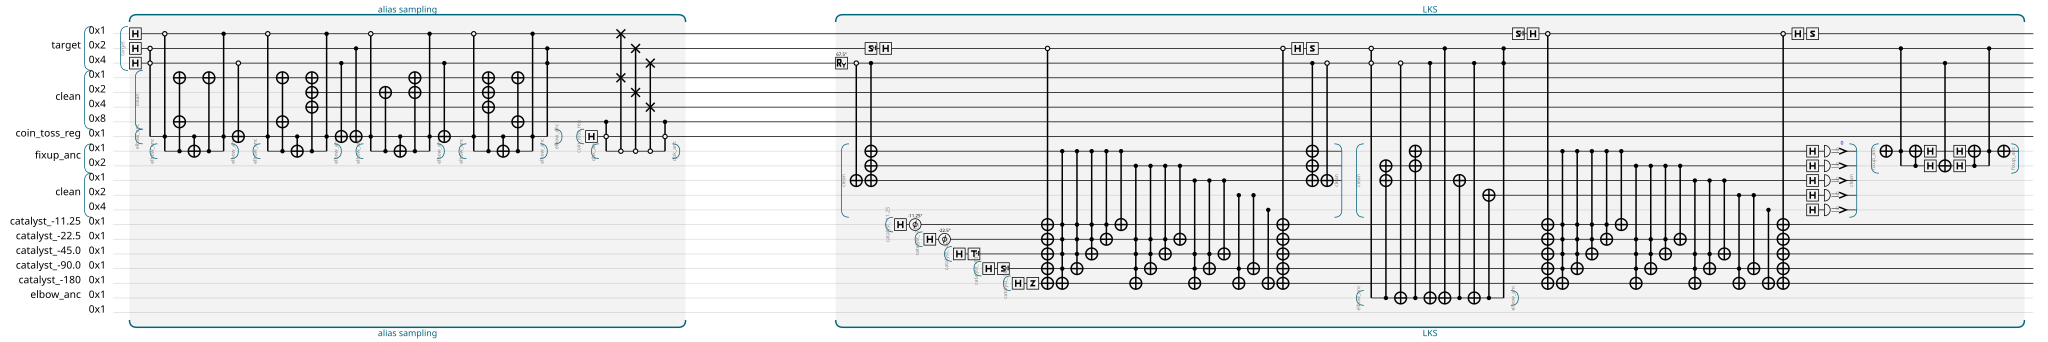

In [2]:
# define coefficients and set up data
n = 3
num_coeffs = 2 ** n
np.random.seed(42)
coeffs = [np.random.rand() for _ in range(num_coeffs)]

epsilon = 2e-1

data = StatePrepData(coeffs, epsilon)

# set up the state prep Qubricks

# first alias sampling
qrom = DataLookupClean(select=BinaryTreeSelect(), swap_up=SwapUp())
usp = USP()
alias_sampling = AliasSampling(qrom=qrom, usp=usp)

# now LKS - there's a lot to choose from here, but we're gonna choose a phase gradient addtion based multiplexor
# try testing your knowledge by picking different choices!
qrom_instance = DataLookupClean(select=BinaryTreeSelect(), swap_up=SwapUp()) # set up the QROM, using the naive version of SELECT for simplicity
rotation_qbk_instance = RotationViaPhaseGradientAddition(adder_qbk=NaiveAdd()) # set up the phase gradient instance (see Sec D.1.2 in the Low et al. paper for details)
mplxr_instance = MultiplexedSingleQubitRotationViaQROM(qrom=qrom_instance, rotation_qbk=rotation_qbk_instance) # put both QROM and phase gradient circuit together
mux_rot = ProgrammableRotArray(op=SupportedOps.RY, mplxr=mplxr_instance) # define the uniformly controlled rotations
lks_state_prep = ArbitraryStatePrep(mux_rot) # finally, build the arbitrary state prep

# now we instantiate the QPU and define our qubits
qc = QPU()
qc.reset(20) # we could be clever and pre-calculate these, but we can also just put in enough to get by

target = Qubits(n, "target", qc)

# now we compute our state preps with the same arguments!
qc.label("alias sampling")
alias_sampling.compute(target, data)
qc.label()

# just to space things out a bit
for _ in range(10):
    qc.nop()

qc.label("LKS")
lks_state_prep.compute(target, data)
qc.label()

qc.draw()

Now this still looks like an awful lot of boilerplate, but (a) a lot of it is unavoidable (how can we specify that we want to prepare a particular state without putting the coefficients down?) and (b) most of it is the same between our two sets of Qubricks. In the next cell, we have exactly the same code, but the "Qubrick-specific" code (that is, code that you need to change to swap between `AliasSampling` and `ArbitraryStatePrep`) has been commented out, showing how much of the code is shared between the two (and can therefore be re-used):

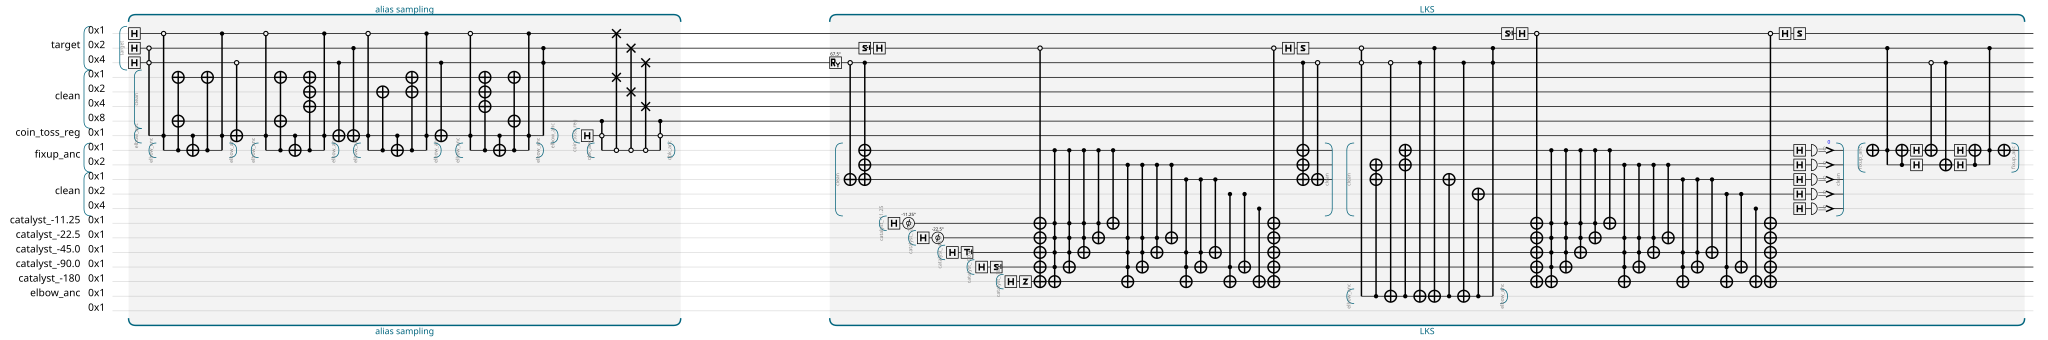

In [3]:
n = 3
num_coeffs = 2 ** n
np.random.seed(42)
coeffs = [np.random.rand() for _ in range(num_coeffs)]

epsilon = 2e-1

data = StatePrepData(coeffs, epsilon)

########################### Qubrick-specific code ##############################
# note that this cell requires the previous one to be executed in order for this to work.
# # set up the state prep Qubricks

# # first alias sampling
# qrom = DataLookupClean(select=BinaryTreeSelect(), swap_up=SwapUp())
# usp = USP()
# alias_sampling = AliasSampling(qrom=qrom, usp=usp)

# # now LKS - there's a lot to choose from here, but we're gonna choose a phase gradient addtion based multiplexor
# # try testing your knowledge by picking different choices!
# qrom_instance = DataLookupClean(select=BinaryTreeSelect(), swap_up=SwapUp()) # set up the QROM, using the naive version of SELECT for simplicity
# rotation_qbk_instance = RotationViaPhaseGradientAddition() # set up the phase gradient instance (see Sec D.1.2 in the Low et al. paper for details)
# mplxr_instance = MultiplexedSingleQubitRotationViaQROM(qrom=qrom_instance, rotation_qbk=rotation_qbk_instance) # put both QROM and phase gradient circuit together
# mux_rot = ProgrammableRotArray(op=SupportedOps.RY, mplxr=mplxr_instance) # define the uniformly controlled rotations
# lks_state_prep = ArbitraryStatePrep(mux_rot) # finally, build the arbitrary state prep
################################################################################

# now we instantiate the QPU and define our qubits
qc = QPU()
qc.reset(20) # we could be clever and pre-calculate these, but we can also just put in enough to get by

target = Qubits(n, "target", qc)

# now we compute our state preps with the same arguments!
qc.label("alias sampling")
alias_sampling.compute(target, data)
qc.label()

# just to space things out a bit
for _ in range(10):
    qc.nop()

qc.label("LKS")
lks_state_prep.compute(target, data)
qc.label()

qc.draw()

We can highlight this even more by using the Qubrick dependency injection framework to build the Qubricks, which allows us to pull out common functionality. Note that currently very few Qubricks are integrated into the DI framework, and no default configurations have been defined, so the advantage of using the DI framework is fairly limited, but in the future the idea is to have several different configurations that can be specified with a single line (and overwritten as needed). For now, here's what we have:

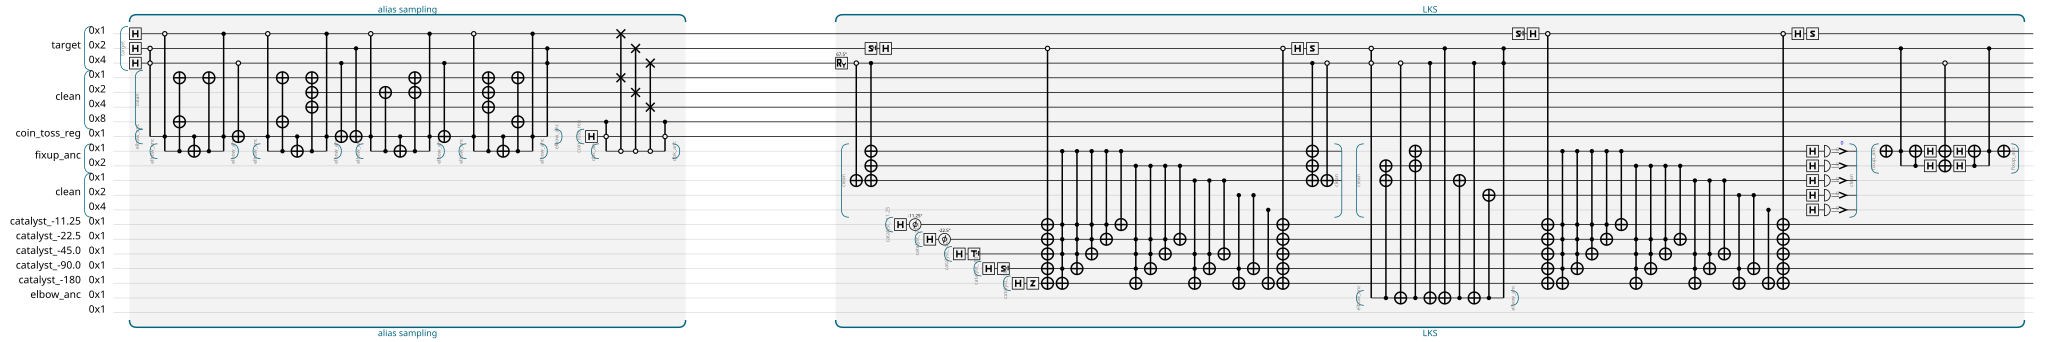

In [4]:
n = 3
num_coeffs = 2 ** n
np.random.seed(42)
coeffs = [np.random.rand() for _ in range(num_coeffs)]

epsilon = 2e-1

data = StatePrepData(coeffs, epsilon)

# set up the state prep Qubricks using the DI controller

# general Qubrick definitions
controller = QubrickInjectionManager()

qrom = partial(DataLookupClean, select=BinaryTreeSelect(), swap_up=SwapUp())
controller.register(QROM, qrom)
controller.register(UniformStatePreparation, USP)
controller.register(Adder, NaiveAdd)
controller.register(AmplitudePreparation, ProgrammableRotArray, op=SupportedOps.RY)
controller.register(PhasePreparation, ProgrammableRotArray, op=SupportedOps.RZ)
controller.register(MultiplexedRotations, MultiplexedSingleQubitRotationViaQROM)
controller.register(SuperpositionRotations, RotationViaPhaseGradientAddition)

# construct alias sampling
alias_sampling = controller.construct(AliasSampling)

# construct LKS
lks_state_prep = controller.construct(ArbitraryStatePrep)

# now we instantiate the QPU and define our qubits
qc = QPU()
qc.reset(20) # we could be clever and pre-calculate these, but we can also just put in enough to get by

target = Qubits(n, "target", qc)

# now we compute our state preps with the same arguments!
qc.label("alias sampling")
alias_sampling.compute(target, data)
qc.label()

# just to space things out a bit
for _ in range(10):
    qc.nop()

qc.label("LKS")
lks_state_prep.compute(target, data)
qc.label()

qc.draw()